In [2]:
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
from datetime import datetime

print("All imports successful")
print(f"GeoPandas version: {gpd.__version__}")

All imports successful
GeoPandas version: 1.1.3


In [8]:
# ── Study period ──────────────────────────────────────────────────────────────
WARM_SEASON_START = "2024-04-01"
WARM_SEASON_END   = "2024-09-30"

MONTHS = [
    ("2024-04-01T00:00Z", "2024-04-30T23:59Z", "April"),
    ("2024-05-01T00:00Z", "2024-05-31T23:59Z", "May"),
    ("2024-06-01T00:00Z", "2024-06-30T23:59Z", "June"),
    ("2024-07-01T00:00Z", "2024-07-31T23:59Z", "July"),
    ("2024-08-01T00:00Z", "2024-08-31T23:59Z", "August"),
    ("2024-09-01T00:00Z", "2024-09-30T23:59Z", "September"),
]

# ── CONUS bounding box ────────────────────────────────────────────────────────
CONUS_LON_MIN, CONUS_LON_MAX = -125.0, -66.0
CONUS_LAT_MIN, CONUS_LAT_MAX =   24.0,  50.0

# ── Warning filter codes ──────────────────────────────────────────────────────
PHENOMENA    = "FF"
SIGNIFICANCE = "W"

print("Constants defined")
print(f"Study period: {WARM_SEASON_START} to {WARM_SEASON_END}")
print(f"Months defined: {[m[2] for m in MONTHS]}")

Constants defined
Study period: 2024-04-01 to 2024-09-30
Months defined: ['April', 'May', 'June', 'July', 'August', 'September']


In [9]:
import io

def fetch_ffw_one_month(start, end, label):
    """
    Fetch Flash Flood Warning polygons for one month from IEM.
    Fetching month by month avoids server timeouts on large requests.
    """
    url = "https://mesonet.agron.iastate.edu/cgi-bin/request/gis/watchwarn.py"
    
    params = {
        "sts":          start,
        "ets":          end,
        "phenomena":    "FF",
        "significance": "W",
        "fmt":          "shp",
    }
    
    print(f"  Fetching {label}...")
    r = requests.get(url, params=params, timeout=120)
    
    if r.status_code != 200:
        print(f"    ERROR {r.status_code}")
        return None
        
    if len(r.content) < 500:
        print(f"    WARNING: Response too small ({len(r.content)} bytes) — likely empty")
        print(f"    Response: {r.text[:200]}")
        return None
    
    try:
        zip_bytes = io.BytesIO(r.content)
        gdf = gpd.read_file(zip_bytes)
        print(f"    {len(gdf):,} polygons retrieved")
        return gdf
    except Exception as e:
        print(f"    ERROR reading shapefile: {e}")
        print(f"    Response preview: {r.text[:200]}")
        return None


print("=" * 55)
print("Fetching FF Warning polygons — April through September 2024")
print("=" * 55)

monthly_frames = []

for start, end, label in MONTHS:
    gdf = fetch_ffw_one_month(start, end, label)
    if gdf is not None and len(gdf) > 0:
        monthly_frames.append(gdf)

if monthly_frames:
    ffw_raw = pd.concat(monthly_frames, ignore_index=True)
    # Restore geometry after concat
    ffw_raw = gpd.GeoDataFrame(ffw_raw, geometry="geometry")
    print(f"\nTotal FF Warning polygons: {len(ffw_raw):,}")
    print(f"Columns: {ffw_raw.columns.tolist()}")
    print(f"CRS: {ffw_raw.crs}")
else:
    print("No data retrieved — check errors above")

Fetching FF Warning polygons — April through September 2024
  Fetching April...
    45,992 polygons retrieved
  Fetching May...
    59,502 polygons retrieved
  Fetching June...
    44,697 polygons retrieved
  Fetching July...
    51,113 polygons retrieved
  Fetching August...
    45,458 polygons retrieved
  Fetching September...
    26,087 polygons retrieved

Total FF Warning polygons: 272,849
Columns: ['WFO', 'ISSUED', 'EXPIRED', 'INIT_ISS', 'INIT_EXP', 'PHENOM', 'GTYPE', 'SIG', 'ETN', 'STATUS', 'NWS_UGC', 'AREA_KM2', 'UPDATED', 'HV_NWSLI', 'HV_SEV', 'HV_CAUSE', 'HV_REC', 'EMERGENC', 'POLY_BEG', 'POLY_END', 'WINDTAG', 'HAILTAG', 'TORNTAG', 'DAMAGTAG', 'PROD_ID', 'FCSTER', 'VTEC_YR', 'geometry']
CRS: EPSG:4326


In [10]:
print("=" * 55)
print("INSPECTING RAW DATA")
print("=" * 55)

print(f"\nTotal polygons downloaded: {len(ffw_raw):,}")
print(f"\nUnique PHENOM values:")
print(ffw_raw["PHENOM"].value_counts().head(20).to_string())
print(f"\nUnique SIG values:")
print(ffw_raw["SIG"].value_counts().to_string())
print(f"\nUnique GTYPE values:")
print(ffw_raw["GTYPE"].value_counts().to_string())

INSPECTING RAW DATA

Total polygons downloaded: 272,849

Unique PHENOM values:
PHENOM
SV    87814
FA    36335
HT    26650
TO    18804
MA    14755
SC    13773
FF    12849
FL     8812
WI     7977
EH     7787
FW     6813
FG     6189
GL     3294
FR     3259
CF     3109
FZ     2258
HW     2226
TR     1764
BH     1396
RP     1242

Unique SIG values:
SIG
W    134966
Y     86310
A     48291
S      3282

Unique GTYPE values:
GTYPE
C    232586
P     40263


In [11]:
print("=" * 55)
print("FILTERING TO FF WARNING POLYGONS")
print("=" * 55)

print(f"Starting rows: {len(ffw_raw):,}")

# Filter to Flash Flood Warnings with polygon geometry only
ffw_ff = ffw_raw[
    (ffw_raw["PHENOM"] == "FF") &
    (ffw_raw["SIG"]    == "W")  &
    (ffw_raw["GTYPE"]  == "P")
].copy().reset_index(drop=True)

print(f"After filtering FF + W + P (polygon): {len(ffw_ff):,}")

# Check what we have
print(f"\nWFO count: {ffw_ff['WFO'].nunique()} unique offices")
print(f"\nISSUED range: {ffw_ff['ISSUED'].min()} → {ffw_ff['ISSUED'].max()}")
print(f"\nSample rows:")
print(ffw_ff[["WFO", "ISSUED", "EXPIRED", "PHENOM", "SIG", "GTYPE", "AREA_KM2"]].head(10).to_string())

FILTERING TO FF WARNING POLYGONS
Starting rows: 272,849
After filtering FF + W + P (polygon): 3,816

WFO count: 109 unique offices

ISSUED range: 202404010413 → 202409302358

Sample rows:
   WFO        ISSUED       EXPIRED PHENOM SIG GTYPE     AREA_KM2
0  PSR  202404010413  202404010715     FF   W     P   330.625738
1  FWD  202404091759  202404092030     FF   W     P  1990.441580
2  MAF  202404232032  202404232345     FF   W     P  1607.177526
3  SJT  202404280221  202404280530     FF   W     P   980.600520
4  FWD  202404280947  202404281245     FF   W     P  1518.502015
5  OUN  202404302306  202405010215     FF   W     P   287.539818
6  LMK  202404160135  202404160437     FF   W     P    78.512802
7  EAX  202404252244  202404260217     FF   W     P   662.966175
8  PBZ  202404112158  202404120200     FF   W     P  1642.191827
9  JAN  202404081753  202404081845     FF   W     P    77.089672


In [12]:
print("=" * 55)
print("QUALITY CONTROL")
print("=" * 55)

ffw_qc = ffw_ff.copy()
print(f"Starting rows: {len(ffw_qc):,}")

# ── Step 1: Convert timestamps to datetime ────────────────────────────────────
# ISSUED and EXPIRED are currently strings like 202404010413
ffw_qc["ISSUED"]  = pd.to_datetime(ffw_qc["ISSUED"],  format="%Y%m%d%H%M", utc=True)
ffw_qc["EXPIRED"] = pd.to_datetime(ffw_qc["EXPIRED"], format="%Y%m%d%H%M", utc=True)
print(f"\nStep 1 — Timestamps converted to datetime")
print(f"  ISSUED range: {ffw_qc['ISSUED'].min()} → {ffw_qc['ISSUED'].max()}")

# ── Step 2: Drop zero-duration warnings ───────────────────────────────────────
before = len(ffw_qc)
ffw_qc["duration_min"] = (ffw_qc["EXPIRED"] - ffw_qc["ISSUED"]).dt.total_seconds() / 60
ffw_qc = ffw_qc[ffw_qc["duration_min"] > 0].reset_index(drop=True)
print(f"\nStep 2 — Zero-duration warnings removed:")
print(f"  Removed: {before - len(ffw_qc):,}")
print(f"  Remaining: {len(ffw_qc):,}")
print(f"  Duration range: {ffw_qc['duration_min'].min():.0f} → {ffw_qc['duration_min'].max():.0f} minutes")

# ── Step 3: Drop implausible polygon areas ────────────────────────────────────
before = len(ffw_qc)
ffw_qc = ffw_qc[
    (ffw_qc["AREA_KM2"] >= 1) &
    (ffw_qc["AREA_KM2"] <= 50000)
].reset_index(drop=True)
print(f"\nStep 3 — Implausible polygon areas removed (< 1 or > 50,000 km²):")
print(f"  Removed: {before - len(ffw_qc):,}")
print(f"  Remaining: {len(ffw_qc):,}")
print(f"  Area range: {ffw_qc['AREA_KM2'].min():.1f} → {ffw_qc['AREA_KM2'].max():.1f} km²")

# ── Step 4: Drop geometrically invalid polygons ───────────────────────────────
before = len(ffw_qc)
ffw_qc = ffw_qc[ffw_qc["geometry"].is_valid].reset_index(drop=True)
print(f"\nStep 4 — Invalid geometries removed:")
print(f"  Removed: {before - len(ffw_qc):,}")
print(f"  Remaining: {len(ffw_qc):,}")

# ── Step 5: CONUS bounding box ────────────────────────────────────────────────
before = len(ffw_qc)
bounds = ffw_qc["geometry"].bounds  # returns minx, miny, maxx, maxy per row
ffw_qc = ffw_qc[
    (bounds["minx"] >= CONUS_LON_MIN) &
    (bounds["maxx"] <= CONUS_LON_MAX) &
    (bounds["miny"] >= CONUS_LAT_MIN) &
    (bounds["maxy"] <= CONUS_LAT_MAX)
].reset_index(drop=True)
print(f"\nStep 5 — Outside CONUS removed:")
print(f"  Removed: {before - len(ffw_qc):,}")
print(f"  Remaining: {len(ffw_qc):,}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"Final clean dataset: {len(ffw_qc):,} FF Warning polygons")
print(f"Removed total: {len(ffw_ff) - len(ffw_qc):,} ({(len(ffw_ff) - len(ffw_qc))/len(ffw_ff)*100:.1f}%)")
print(f"\nDuration stats (minutes):")
print(ffw_qc["duration_min"].describe().round(1).to_string())
print(f"\nArea stats (km²):")
print(ffw_qc["AREA_KM2"].describe().round(1).to_string())

QUALITY CONTROL
Starting rows: 3,816

Step 1 — Timestamps converted to datetime
  ISSUED range: 2024-04-01 04:13:00+00:00 → 2024-09-30 23:58:00+00:00

Step 2 — Zero-duration warnings removed:
  Removed: 0
  Remaining: 3,816
  Duration range: 3 → 3002 minutes

Step 3 — Implausible polygon areas removed (< 1 or > 50,000 km²):
  Removed: 1
  Remaining: 3,815
  Area range: 2.6 → 20097.2 km²

Step 4 — Invalid geometries removed:
  Removed: 0
  Remaining: 3,815

Step 5 — Outside CONUS removed:
  Removed: 115
  Remaining: 3,700

Final clean dataset: 3,700 FF Warning polygons
Removed total: 116 (3.0%)

Duration stats (minutes):
count    3700.0
mean      197.0
std       106.7
min         3.0
25%       153.0
50%       182.0
75%       195.2
max      3002.0

Area stats (km²):
count     3700.0
mean      1423.8
std       1794.1
min          2.6
25%        325.3
50%        791.8
75%       1867.8
max      20097.2


In [15]:
# Add a unique warning ID for joining in Phase 3
ffw_qc["WARNING_ID"] = range(len(ffw_qc))

ffw_qc.to_parquet(
    "../data/ffw_polygons_ws2024.parquet",
    index=False
)

print(f"Saved → data/ffw_polygons_ws2024.parquet")
print(f"Shape: {ffw_qc.shape}")
print(f"Columns: {ffw_qc.columns.tolist()}")

Saved → data/ffw_polygons_ws2024.parquet
Shape: (3700, 30)
Columns: ['WFO', 'ISSUED', 'EXPIRED', 'INIT_ISS', 'INIT_EXP', 'PHENOM', 'GTYPE', 'SIG', 'ETN', 'STATUS', 'NWS_UGC', 'AREA_KM2', 'UPDATED', 'HV_NWSLI', 'HV_SEV', 'HV_CAUSE', 'HV_REC', 'EMERGENC', 'POLY_BEG', 'POLY_END', 'WINDTAG', 'HAILTAG', 'TORNTAG', 'DAMAGTAG', 'PROD_ID', 'FCSTER', 'VTEC_YR', 'geometry', 'duration_min', 'WARNING_ID']


LSRs loaded: 4,730
FFW polygons: 3,700


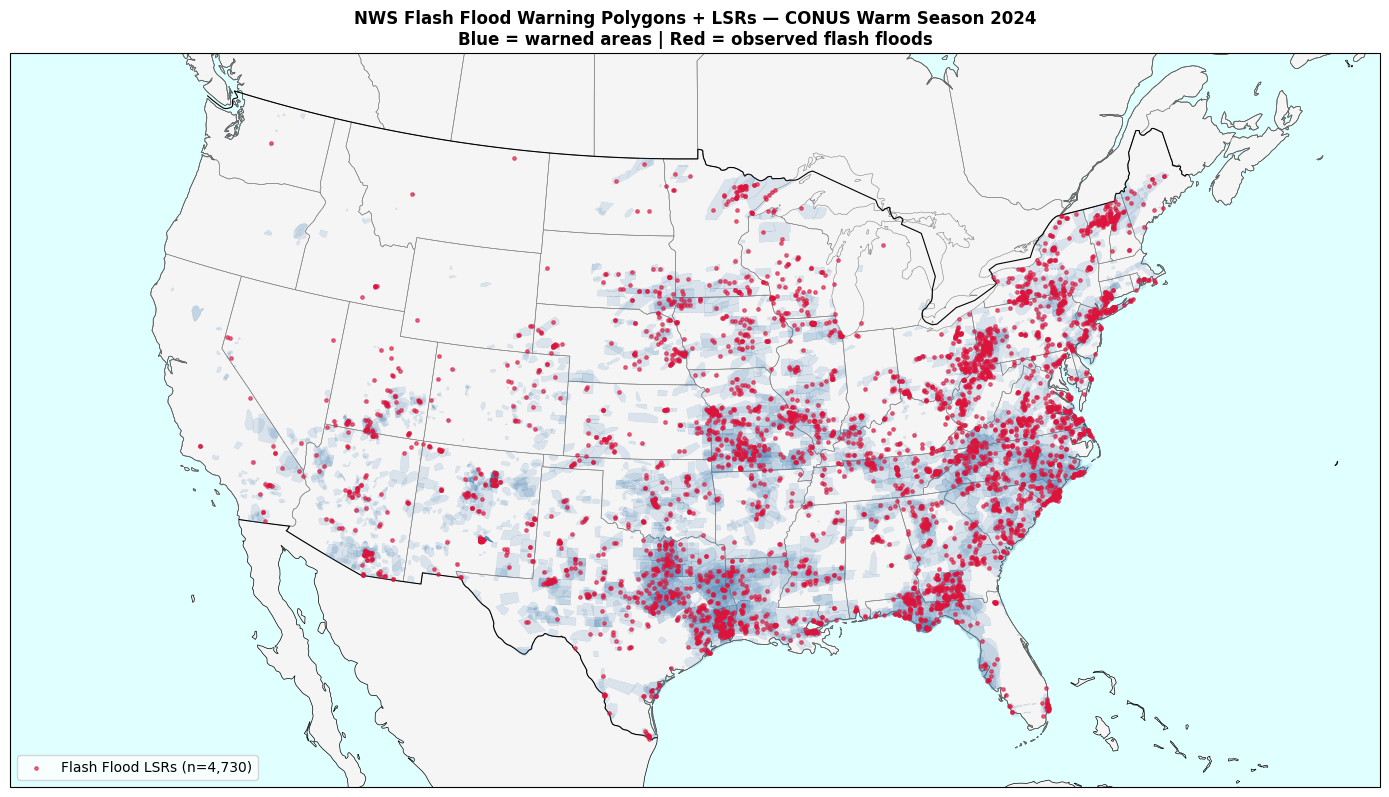

Saved → figures/ffw_lsr_overlay.png


In [16]:
# Load clean LSRs from Phase 1
lsr_qc = pd.read_parquet("../data/lsr_clean_ws2024.parquet", engine="fastparquet")
print(f"LSRs loaded: {len(lsr_qc):,}")
print(f"FFW polygons: {len(ffw_qc):,}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.LambertConformal()}
)

ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,      facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.STATES,    linewidth=0.4, edgecolor="gray")
ax.add_feature(cfeature.BORDERS,   linewidth=0.8, edgecolor="black")

# ── Draw FFW polygons as filled shapes ────────────────────────────────────────
for geom in ffw_qc["geometry"]:
    ax.add_geometries(
        [geom],
        crs=ccrs.PlateCarree(),
        facecolor="steelblue",
        edgecolor="steelblue",
        alpha=0.15,
        linewidth=0.3,
        zorder=3
    )

# ── Plot LSR points on top ────────────────────────────────────────────────────
ax.scatter(
    lsr_qc["LON"],
    lsr_qc["LAT"],
    transform=ccrs.PlateCarree(),
    s=6,
    alpha=0.6,
    color="crimson",
    zorder=5,
    label=f"Flash Flood LSRs (n={len(lsr_qc):,})"
)

ax.legend(loc="lower left", fontsize=10)
ax.set_title(
    "NWS Flash Flood Warning Polygons + LSRs — CONUS Warm Season 2024\n"
    "Blue = warned areas | Red = observed flash floods",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("../figures/ffw_lsr_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/ffw_lsr_overlay.png")